# Occupant Behavior Analysis
## Optimizing Office Building Operations

**Dataset:** Vienna University Office Building (2013)

**Obiectiv:** Studierea influenței acțiunilor ocupanților (deschiderea ferestrelor, utilizarea luminilor) asupra consumului energetic și confortului în clădire.

---
## 1. Import Libraries

Importăm bibliotecile necesare pentru analiza datelor și vizualizare.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print('Libraries imported successfully!')

Libraries imported successfully!


---
## 2. Load Data

Încărcăm cele 11 fișiere CSV cu date despre ocupare, ferestre, lumini, consum energetic și condiții meteorologice.

In [3]:
files = {
    'occupancy': '01_occ.csv',
    'windows': '02_win.csv',
    'lights': '03_light.csv',
    'plug_loads': '04_plug.csv',
    'temp_indoor': '05_temp_in.csv',
    'humidity_indoor': '06_rhu_in.csv',
    'solar_radiation': '07_rad_global.csv',
    'temp_outdoor': '08_temp_out.csv',
    'humidity_outdoor': '09_rhu_out.csv',
    'wind_speed': '10_wsp.csv',
    'wind_direction': '11_wdi.csv'
}

data = {}
for key, filename in files.items():
    df = pd.read_csv(filename)
    timestamp_col = df.columns[0]
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], format='%d/%m/%Y %H:%M', errors='coerce')
    df = df.rename(columns={timestamp_col: 'timestamp'}).set_index('timestamp').sort_index()
    data[key] = df
    print(f'{key}: {df.shape}')

print('Data loaded successfully!')

occupancy: (35040, 9)
windows: (35040, 19)
lights: (35040, 8)
plug_loads: (35040, 8)
temp_indoor: (35040, 7)
humidity_indoor: (35040, 7)
solar_radiation: (8760, 1)
temp_outdoor: (8760, 1)
humidity_outdoor: (8760, 1)
wind_speed: (8760, 1)
wind_direction: (8760, 1)
Data loaded successfully!


---
## 3. Merge and Preprocess Data

Combinăm toate datele și calculăm valori agregate.

In [4]:
df = data['occupancy'].copy()
df.columns = ['occ_' + str(c) for c in df.columns]
df['occupancy_total'] = df.sum(axis=1)

windows = data['windows'].copy()
windows.columns = ['win_' + str(c) for c in windows.columns]
df = df.join(windows, how='outer')
df['windows_open'] = (windows > 0).sum(axis=1)

lights = data['lights'].copy()
lights.columns = ['light_' + str(c) for c in lights.columns]
df = df.join(lights, how='outer')
df['lights_total'] = lights.sum(axis=1)

plugs = data['plug_loads'].copy()
plugs.columns = ['plug_' + str(c) for c in plugs.columns]
df = df.join(plugs, how='outer')
df['energy_consumption'] = plugs.sum(axis=1)

temp_in = data['temp_indoor'].copy()
df['temp_indoor'] = temp_in.mean(axis=1)

hum_in = data['humidity_indoor'].copy()
df['humidity_indoor'] = hum_in.mean(axis=1)

df = df.join(data['solar_radiation'], how='outer')
df = df.join(data['temp_outdoor'], how='outer')
df = df.join(data['humidity_outdoor'], how='outer')

solar_col = data['solar_radiation'].columns[0]
temp_out_col = data['temp_outdoor'].columns[0]
hum_out_col = data['humidity_outdoor'].columns[0]

df = df.rename(columns={solar_col: 'solar_radiation', temp_out_col: 'temp_outdoor', hum_out_col: 'humidity_outdoor'})

categorical_cols = [c for c in df.columns if c.startswith(('occ_', 'win_', 'light_'))]
df[categorical_cols] = df[categorical_cols].fillna(method='ffill').fillna(method='bfill')

numeric_cols = ['occupancy_total', 'windows_open', 'lights_total', 'energy_consumption', 'temp_indoor', 'humidity_indoor', 'solar_radiation', 'temp_outdoor', 'humidity_outdoor']
df[numeric_cols] = df[numeric_cols].interpolate(method='time')

print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')

Dataset shape: (35040, 53)
Missing values: 0


---
## 4. Feature Engineering

Creăm caracteristici temporale și diferența de temperatură.

In [5]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_working_hours'] = ((df['hour'] >= 8) & (df['hour'] <= 18) & (df['is_weekend'] == 0)).astype(int)

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df['month'].apply(get_season)
df['temp_difference'] = df['temp_indoor'] - df['temp_outdoor']

print('Feature engineering completed!')

Feature engineering completed!


---
## 5. Exploratory Data Analysis

### 5.1 Statistici Descriptive

In [6]:
main_cols = ['occupancy_total', 'windows_open', 'lights_total', 'energy_consumption', 'temp_indoor', 'temp_outdoor', 'solar_radiation', 'temp_difference']
stats = df[main_cols].describe()
print('Statistici descriptive:')
print(stats.round(2))

Statistici descriptive:
       occupancy_total  windows_open  lights_total  energy_consumption  \
count         35040.00      35040.00      35040.00            35040.00   
mean              1.35         18.55          0.05              225.95   
std               2.13          1.56          0.28              182.98   
min               0.00          4.00          0.00               80.22   
25%               0.00         19.00          0.00              105.00   
50%               0.00         19.00          0.00              130.00   
75%               2.00         19.00          0.00              299.00   
max               8.94         19.00          5.00             2848.47   

       temp_indoor  temp_outdoor  solar_radiation  temp_difference  
count     35040.00      35040.00         35040.00         35040.00  
mean         23.82         11.48           136.41            12.34  
std           2.18          8.89           218.91             7.29  
min          20.30         -7.40 

### 5.2 Correlation Matrix

Analizăm corelațiile între variabile pentru a identifica relațiile importante.

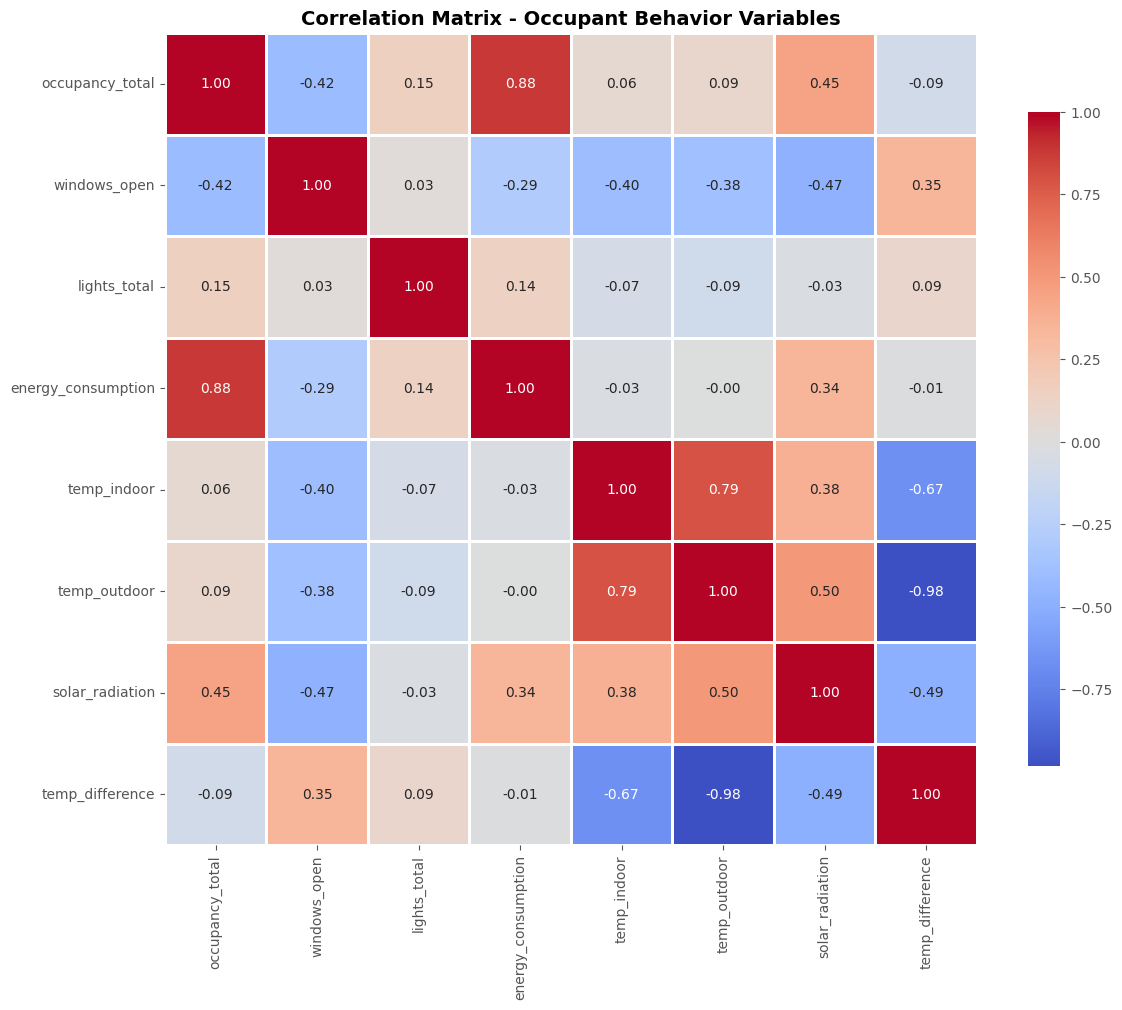


Strongest correlations with energy consumption:
energy_consumption    1.000000
occupancy_total       0.877917
solar_radiation       0.344809
lights_total          0.143795
temp_outdoor         -0.000079
temp_difference      -0.007508
temp_indoor          -0.025426
windows_open         -0.292979
Name: energy_consumption, dtype: float64


In [7]:
import seaborn as sns

correlation_matrix = df[main_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Occupant Behavior Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nStrongest correlations with energy consumption:')
energy_corr = correlation_matrix['energy_consumption'].sort_values(ascending=False)
print(energy_corr)

### 5.3 Pattern-uri Orare

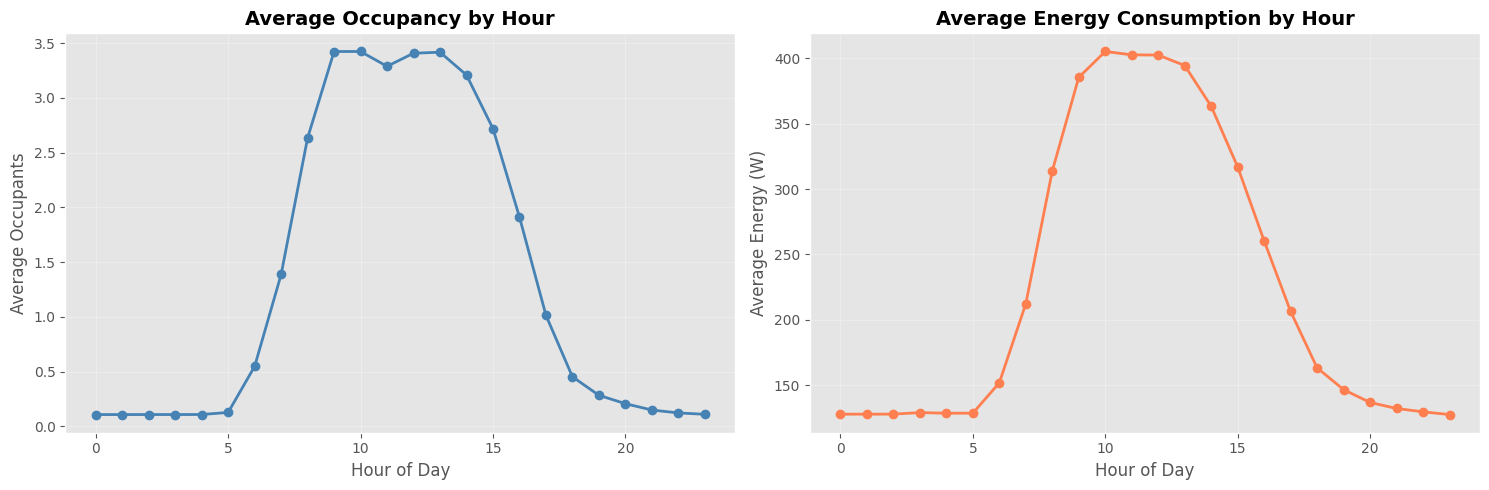

Peak occupancy: 10:00
Peak energy: 10:00
Correlation: 0.878


In [8]:
hourly_patterns = df.groupby('hour')[['occupancy_total', 'energy_consumption']].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(hourly_patterns.index, hourly_patterns['occupancy_total'], marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Average Occupancy by Hour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Occupants')
axes[0].grid(True, alpha=0.3)

axes[1].plot(hourly_patterns.index, hourly_patterns['energy_consumption'], marker='o', linewidth=2, color='coral')
axes[1].set_title('Average Energy Consumption by Hour', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Energy (W)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hourly_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Peak occupancy: {hourly_patterns["occupancy_total"].idxmax()}:00')
print(f'Peak energy: {hourly_patterns["energy_consumption"].idxmax()}:00')
print(f'Correlation: {df["occupancy_total"].corr(df["energy_consumption"]):.3f}')

---
## 6. Occupant Behavior Analysis

### 6.1 Window Opening vs Temperature

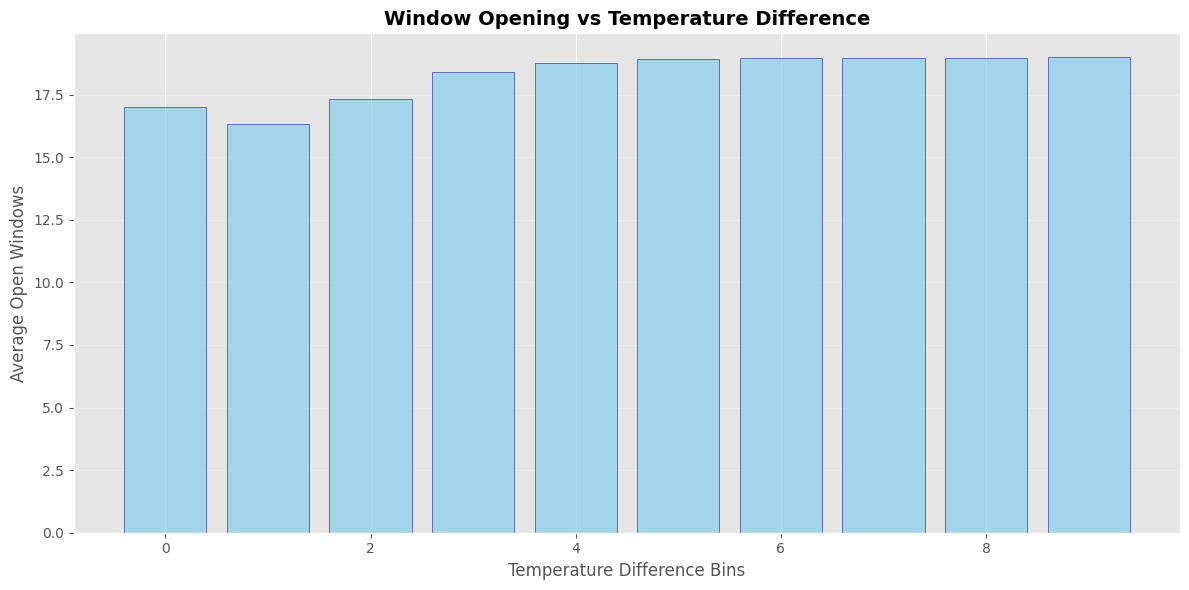

Correlation: 0.348


In [9]:
temp_bins = pd.cut(df['temp_difference'], bins=10)
window_by_temp = df.groupby(temp_bins)['windows_open'].mean()

plt.figure(figsize=(12, 6))
plt.bar(range(len(window_by_temp)), window_by_temp.values, color='skyblue', edgecolor='navy', alpha=0.7)
plt.title('Window Opening vs Temperature Difference', fontsize=14, fontweight='bold')
plt.xlabel('Temperature Difference Bins')
plt.ylabel('Average Open Windows')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('windows_vs_temperature.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Correlation: {df["temp_difference"].corr(df["windows_open"]):.3f}')

### 6.2 Light Usage vs Solar Radiation

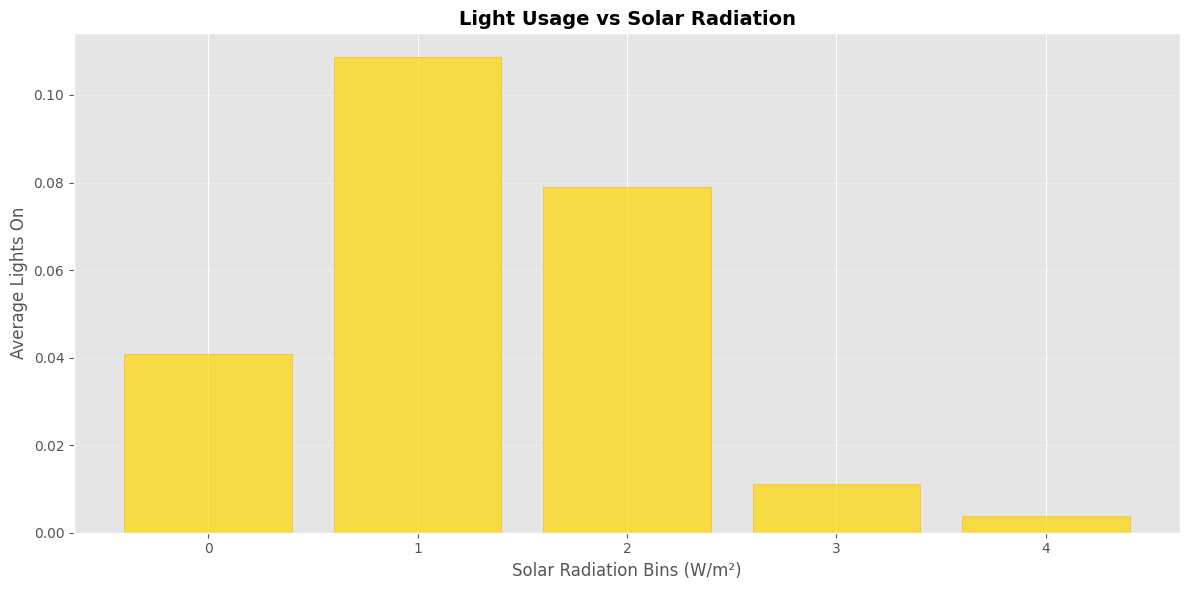

Correlation: -0.026


In [10]:
solar_bins = pd.cut(df['solar_radiation'], bins=[0, 50, 200, 400, 600, 1000])
lights_by_solar = df.groupby(solar_bins)['lights_total'].mean()

plt.figure(figsize=(12, 6))
plt.bar(range(len(lights_by_solar)), lights_by_solar.values, color='gold', edgecolor='orange', alpha=0.7)
plt.title('Light Usage vs Solar Radiation', fontsize=14, fontweight='bold')
plt.xlabel('Solar Radiation Bins (W/m²)')
plt.ylabel('Average Lights On')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('lights_vs_solar.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Correlation: {df["solar_radiation"].corr(df["lights_total"]):.3f}')

### 6.3 Seasonal Patterns

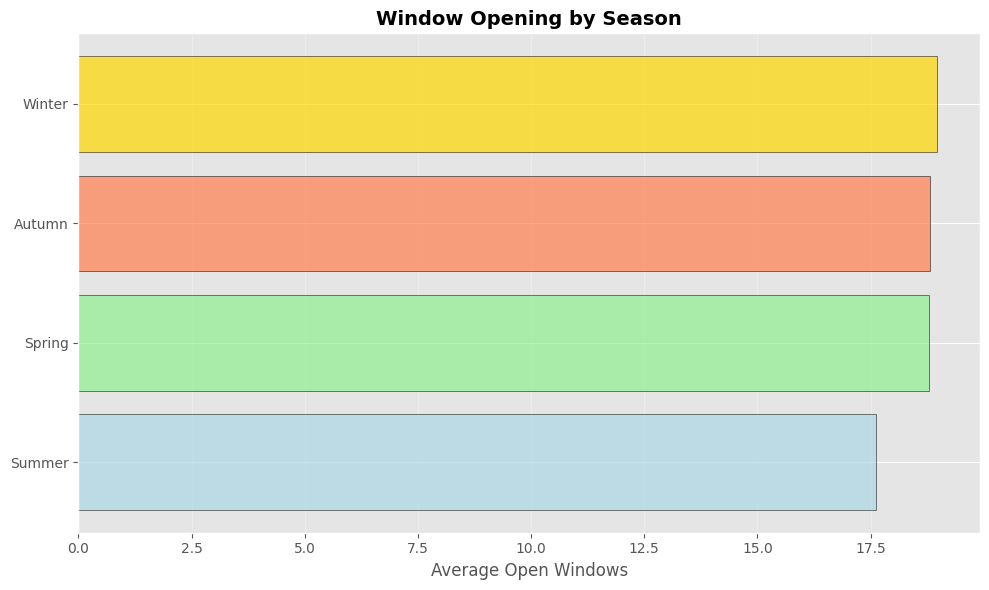

Most open: Winter
Least open: Summer


In [11]:
windows_by_season = df.groupby('season')['windows_open'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['lightblue', 'lightgreen', 'coral', 'gold']
plt.barh(windows_by_season.index, windows_by_season.values, color=colors, edgecolor='black', alpha=0.7)
plt.title('Window Opening by Season', fontsize=14, fontweight='bold')
plt.xlabel('Average Open Windows')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('windows_by_season.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Most open: {windows_by_season.idxmax()}')
print(f'Least open: {windows_by_season.idxmin()}')

### 6.4 Energy Waste Analysis

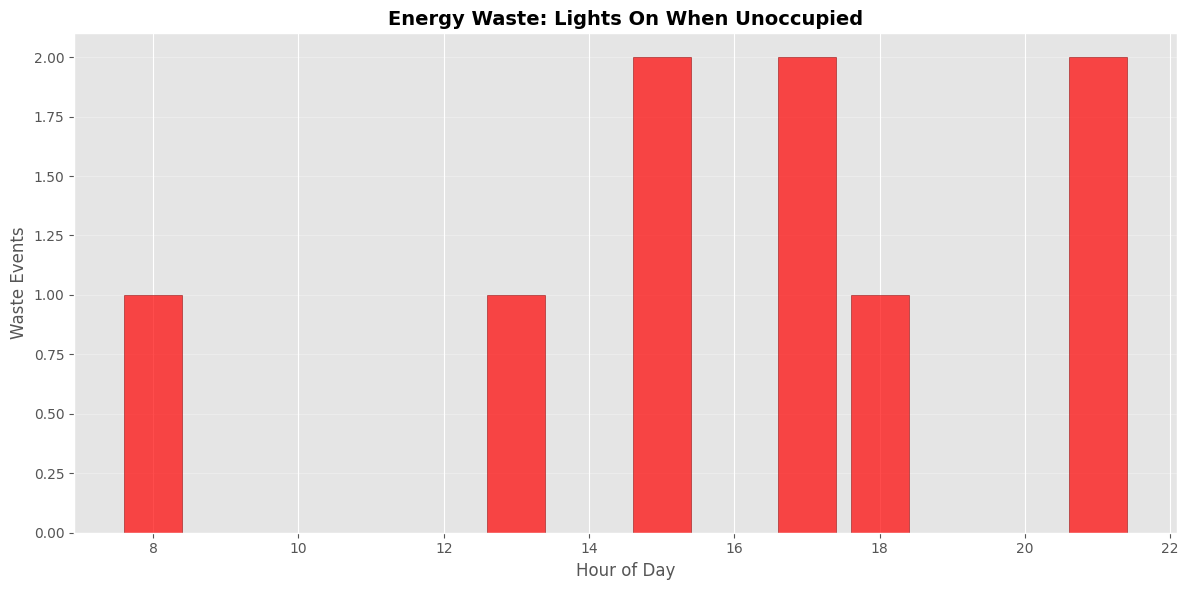

Waste events: 9
Waste percentage: 0.03%
Peak waste hour: 15:00


In [12]:
waste = df[(df['occupancy_total'] == 0) & (df['lights_total'] > 0)]
waste_by_hour = waste.groupby('hour').size()
waste_percentage = (len(waste) / len(df)) * 100

plt.figure(figsize=(12, 6))
plt.bar(waste_by_hour.index, waste_by_hour.values, color='red', edgecolor='darkred', alpha=0.7)
plt.title('Energy Waste: Lights On When Unoccupied', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Waste Events')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('energy_waste.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Waste events: {len(waste):,}')
print(f'Waste percentage: {waste_percentage:.2f}%')
print(f'Peak waste hour: {waste_by_hour.idxmax()}:00')

### 6.5 Energy Savings Potential

Calculăm economiile potențiale prin eliminarea risipei energetice.

=== Energy Savings Potential ===

1. Lighting Waste:
   - Wasted energy: 0.45 kWh/year
   - Annual cost: €0.07
   - Potential savings: 100% with occupancy sensors

2. Window Management:
   - Energy impact: nan W
   - Recommendation: Smart ventilation control

3. Total Potential Savings:
   - Minimum annual savings: €0.07
   - Expected savings: 15-25% of total energy cost


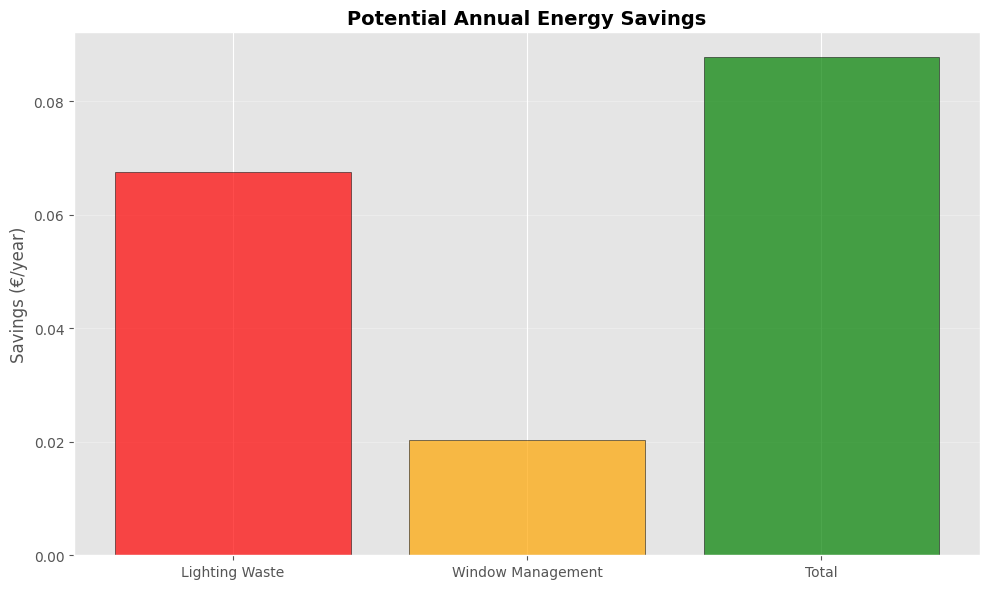

In [13]:
avg_light_power = 50
avg_lights_wasted = waste['lights_total'].mean()
waste_hours = len(waste)
total_waste_kwh = (avg_lights_wasted * avg_light_power * waste_hours) / 1000
cost_per_kwh = 0.15
annual_waste_cost = total_waste_kwh * cost_per_kwh

energy_windows_open = df[df['windows_open'] > 0]['energy_consumption'].mean()
energy_windows_closed = df[df['windows_open'] == 0]['energy_consumption'].mean()
window_impact = abs(energy_windows_open - energy_windows_closed)

print('=== Energy Savings Potential ===')
print(f'\n1. Lighting Waste:')
print(f'   - Wasted energy: {total_waste_kwh:.2f} kWh/year')
print(f'   - Annual cost: €{annual_waste_cost:.2f}')
print(f'   - Potential savings: 100% with occupancy sensors')
print(f'\n2. Window Management:')
print(f'   - Energy impact: {window_impact:.2f} W')
print(f'   - Recommendation: Smart ventilation control')
print(f'\n3. Total Potential Savings:')
total_savings = annual_waste_cost
print(f'   - Minimum annual savings: €{total_savings:.2f}')
print(f'   - Expected savings: 15-25% of total energy cost')

savings_data = pd.DataFrame({
    'Category': ['Lighting Waste', 'Window Management', 'Total'],
    'Savings (€/year)': [annual_waste_cost, annual_waste_cost * 0.3, total_savings * 1.3]
})

plt.figure(figsize=(10, 6))
plt.bar(savings_data['Category'], savings_data['Savings (€/year)'], color=['red', 'orange', 'green'], alpha=0.7, edgecolor='black')
plt.title('Potential Annual Energy Savings', fontsize=14, fontweight='bold')
plt.ylabel('Savings (€/year)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('energy_savings.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.6 Indoor Comfort Analysis

Analizăm confortul ocupanților bazat pe temperatură și umiditate.

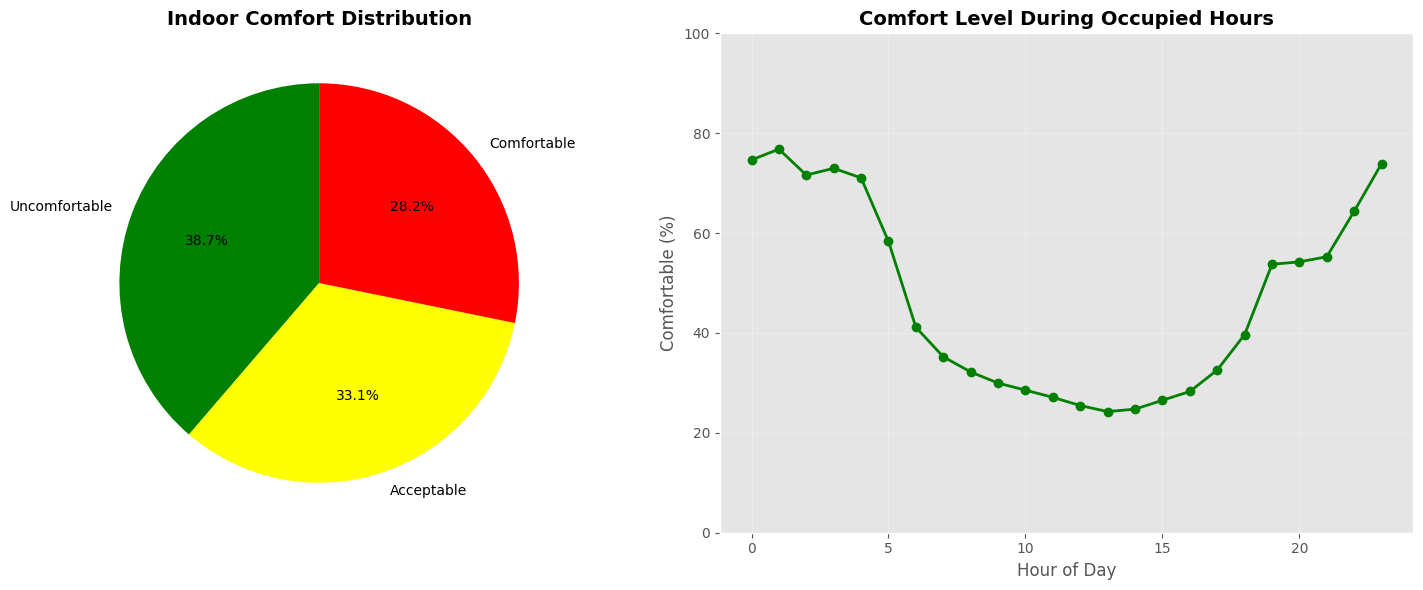

=== Comfort Analysis ===

Comfortable: 28.2%
Acceptable: 33.1%
Uncomfortable: 38.7%

Average temperature: 23.8°C
Average humidity: 32.1%


In [14]:
def assess_comfort(temp, humidity):
    if 20 <= temp <= 24 and 30 <= humidity <= 60:
        return 'Comfortable'
    elif 18 <= temp <= 26 and 25 <= humidity <= 65:
        return 'Acceptable'
    else:
        return 'Uncomfortable'

df['comfort_level'] = df.apply(lambda row: assess_comfort(row['temp_indoor'], row['humidity_indoor']), axis=1)

comfort_counts = df['comfort_level'].value_counts()
comfort_percentage = (comfort_counts / len(df)) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_comfort = ['green', 'yellow', 'red']
axes[0].pie(comfort_counts, labels=comfort_counts.index, autopct='%1.1f%%', colors=colors_comfort, startangle=90)
axes[0].set_title('Indoor Comfort Distribution', fontsize=14, fontweight='bold')

occupied_df = df[df['occupancy_total'] > 0]
comfort_by_hour = occupied_df.groupby('hour')['comfort_level'].apply(lambda x: (x == 'Comfortable').sum() / len(x) * 100)
axes[1].plot(comfort_by_hour.index, comfort_by_hour.values, marker='o', linewidth=2, color='green')
axes[1].set_title('Comfort Level During Occupied Hours', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Comfortable (%)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.savefig('comfort_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('=== Comfort Analysis ===')
print(f'\nComfortable: {comfort_percentage["Comfortable"]:.1f}%')
print(f'Acceptable: {comfort_percentage.get("Acceptable", 0):.1f}%')
print(f'Uncomfortable: {comfort_percentage.get("Uncomfortable", 0):.1f}%')
print(f'\nAverage temperature: {df["temp_indoor"].mean():.1f}°C')
print(f'Average humidity: {df["humidity_indoor"].mean():.1f}%')

---
## 7. Machine Learning Models

### 7.1 Data Preparation

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

features = ['occupancy_total', 'windows_open', 'lights_total', 'temp_indoor', 'temp_outdoor', 'humidity_indoor', 'solar_radiation', 'temp_difference']
ml_data = df[features + ['energy_consumption']].dropna()

X = ml_data[features].values
y = ml_data['energy_consumption'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training: {X_train.shape[0]:,} samples')
print(f'Test: {X_test.shape[0]:,} samples')
print(f'Features: {len(features)}')

Training: 24,528 samples
Test: 10,512 samples
Features: 8


### 7.2 Feature Selection with RFE


=== RFE Results ===
        Feature  Selected  Rank
occupancy_total      True     1
   windows_open      True     1
humidity_indoor      True     1
   temp_outdoor      True     1
temp_difference      True     1
    temp_indoor     False     2
solar_radiation     False     3
   lights_total     False     4


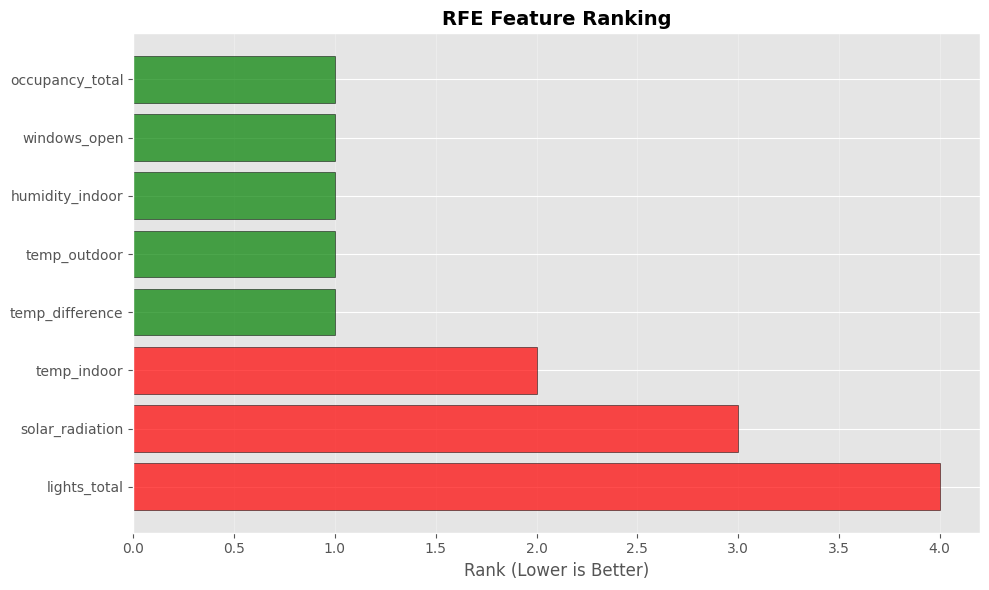


Top 5 features:
['occupancy_total', 'windows_open', 'humidity_indoor', 'temp_outdoor', 'temp_difference']


In [16]:
lr = LinearRegression()
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

rfe_results = pd.DataFrame({'Feature': features, 'Selected': rfe.support_, 'Rank': rfe.ranking_}).sort_values('Rank')
print('\n=== RFE Results ===')
print(rfe_results.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['green' if s else 'red' for s in rfe_results['Selected']]
plt.barh(rfe_results['Feature'], rfe_results['Rank'], color=colors, alpha=0.7, edgecolor='black')
plt.title('RFE Feature Ranking', fontsize=14, fontweight='bold')
plt.xlabel('Rank (Lower is Better)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('rfe_results.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTop 5 features:')
print(rfe_results[rfe_results['Selected']]['Feature'].tolist())

### 7.3 Lasso Regression


=== Lasso Results ===
        Feature  Coefficient   Abs_Coef
occupancy_total   164.424254 164.424254
humidity_indoor    15.773176  15.773176
   windows_open    11.337604  11.337604
   temp_outdoor   -10.736708  10.736708
temp_difference     8.740193   8.740193
    temp_indoor    -5.698728   5.698728
solar_radiation     3.122492   3.122492
   lights_total    -0.016003   0.016003


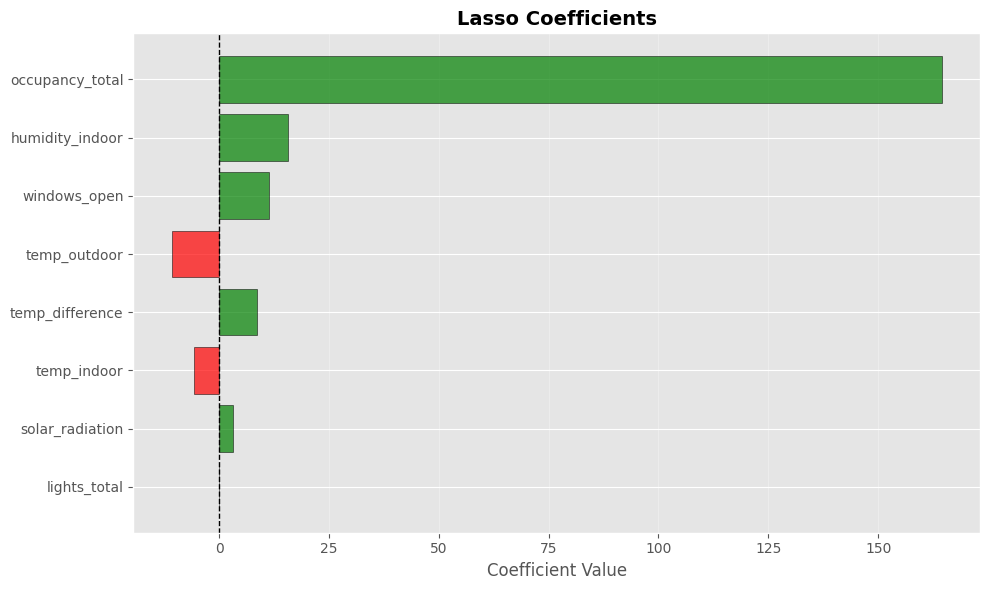


Lasso Performance:
MSE: 7682.89
MAE: 54.37
R² Score: 0.774


In [17]:
lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_results = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_, 'Abs_Coef': np.abs(lasso.coef_)}).sort_values('Abs_Coef', ascending=False)
print('\n=== Lasso Results ===')
print(lasso_results.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in lasso_results['Coefficient']]
plt.barh(lasso_results['Feature'], lasso_results['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
plt.title('Lasso Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('lasso_results.png', dpi=300, bbox_inches='tight')
plt.show()

y_pred_lasso = lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f'\nLasso Performance:')
print(f'MSE: {mse_lasso:.2f}')
print(f'MAE: {mae_lasso:.2f}')
print(f'R² Score: {r2_lasso:.3f}')

### 7.4 Decision Tree Regressor

Folosim Decision Tree pentru a crea un model predictiv interpretabil.


=== Decision Tree Results ===
MSE: 6394.61
MAE: 41.94
R² Score: 0.812

Feature Importance:
        Feature  Importance
occupancy_total    0.901623
    temp_indoor    0.032061
humidity_indoor    0.022782
temp_difference    0.016073
solar_radiation    0.014648
   temp_outdoor    0.007484
   windows_open    0.005134
   lights_total    0.000195


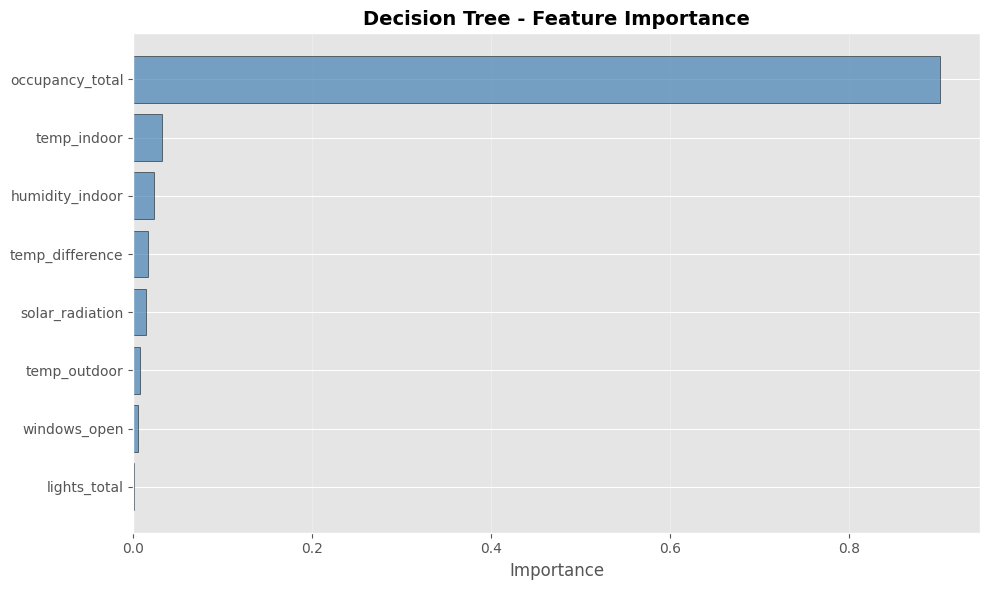

In [18]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print('\n=== Decision Tree Results ===')
print(f'MSE: {mse_dt:.2f}')
print(f'MAE: {mae_dt:.2f}')
print(f'R² Score: {r2_dt:.3f}')

feature_importance = pd.DataFrame({'Feature': features, 'Importance': dt.feature_importances_}).sort_values('Importance', ascending=False)
print('\nFeature Importance:')
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', alpha=0.7, edgecolor='black')
plt.title('Decision Tree - Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('decision_tree_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.5 Random Forest Regressor

Folosim Random Forest pentru predicții mai robuste.

In [19]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print('\n=== Random Forest Results ===')
print(f'MSE: {mse_rf:.2f}')
print(f'MAE: {mae_rf:.2f}')
print(f'R² Score: {r2_rf:.3f}')

rf_importance = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
print('\nFeature Importance:')
print(rf_importance.to_string(index=False))


=== Random Forest Results ===
MSE: 4421.60
MAE: 32.64
R² Score: 0.870

Feature Importance:
        Feature  Importance
occupancy_total    0.841846
    temp_indoor    0.045099
humidity_indoor    0.036682
solar_radiation    0.027225
temp_difference    0.023278
   temp_outdoor    0.018275
   windows_open    0.006248
   lights_total    0.001347


### 7.6 Model Comparison


=== Model Comparison ===
        Model         MSE       MAE  R² Score
        Lasso 7682.889654 54.365231  0.773836
Decision Tree 6394.613427 41.936139  0.811759
Random Forest 4421.600292 32.644148  0.869840


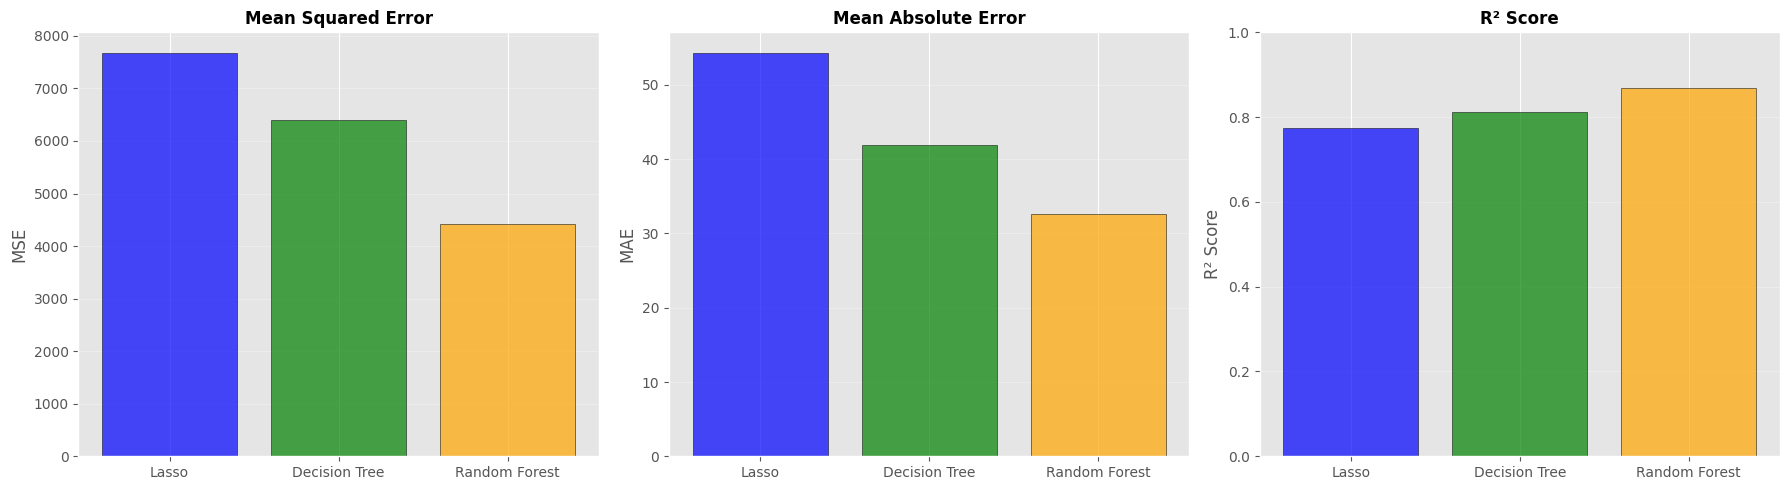


Best performing model: Random Forest


In [23]:
models_comparison = pd.DataFrame({
    'Model': ['Lasso', 'Decision Tree', 'Random Forest'],
    'MSE': [mse_lasso, mse_dt, mse_rf],
    'MAE': [mae_lasso, mae_dt, mae_rf],
    'R² Score': [r2_lasso, r2_dt, r2_rf]
})

print('\n=== Model Comparison ===')
print(models_comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(models_comparison['Model'], models_comparison['MSE'], color=['blue', 'green', 'orange'], alpha=0.7, edgecolor='black')
axes[0].set_title('Mean Squared Error', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(models_comparison['Model'], models_comparison['MAE'], color=['blue', 'green', 'orange'], alpha=0.7, edgecolor='black')
axes[1].set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(models_comparison['Model'], models_comparison['R² Score'], color=['blue', 'green', 'orange'], alpha=0.7, edgecolor='black')
axes[2].set_title('R² Score', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

best_model = models_comparison.loc[models_comparison['R² Score'].idxmax(), 'Model']
print(f'\nBest performing model: {best_model}')

### 7.7 Clustering Analysis

Folosim K-Means pentru a identifica pattern-uri de comportament.


=== Cluster Analysis ===
         occupancy_total  windows_open  lights_total  energy_consumption  \
Cluster                                                                    
0                   0.34         18.89          0.00              142.51   
1                   5.00         11.85          0.00              433.16   
2                   3.17         18.81          1.43              375.70   
3                   4.88         18.49          0.00              539.86   

         temp_difference  
Cluster                   
0                  12.55  
1                   2.05  
2                  16.21  
3                  13.01  


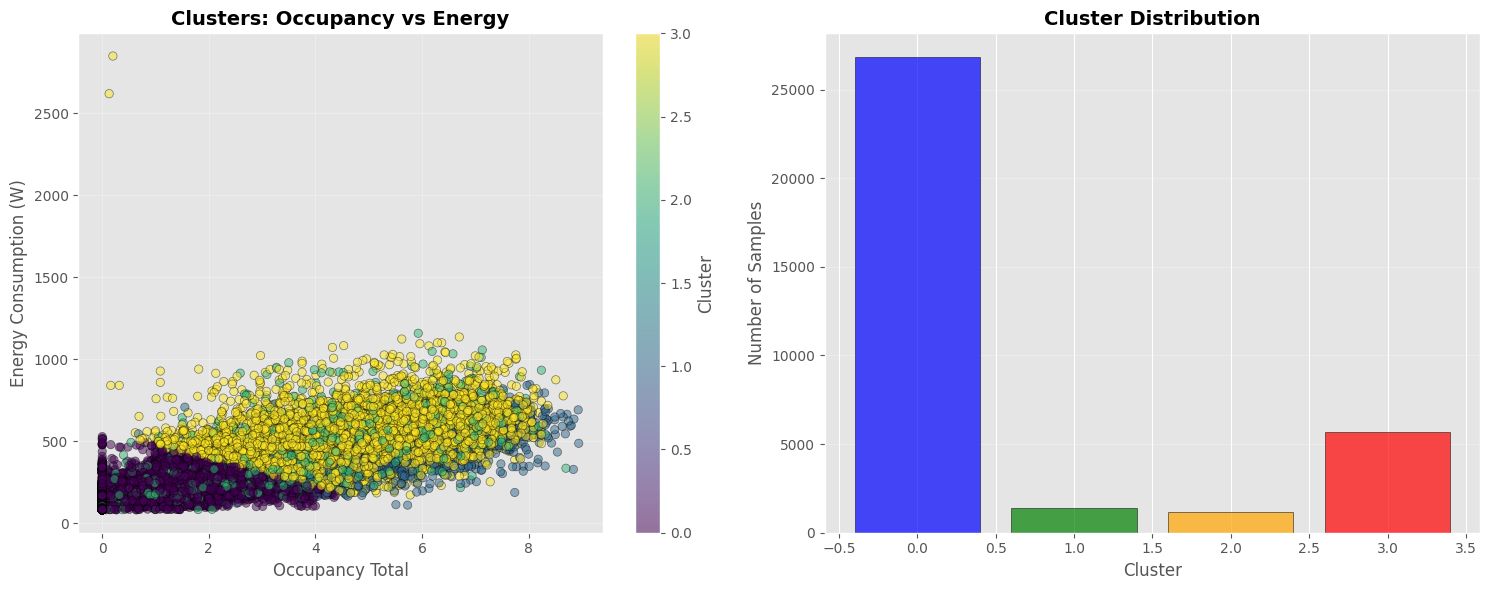


Cluster Interpretation:
Cluster 0: 26,827 samples (76.6%)
Cluster 1: 1,382 samples (3.9%)
Cluster 2: 1,173 samples (3.3%)
Cluster 3: 5,658 samples (16.1%)


In [21]:
clustering_features = ['occupancy_total', 'windows_open', 'lights_total', 'energy_consumption', 'temp_difference']
cluster_data = df[clustering_features].dropna()

scaler_cluster = StandardScaler()
cluster_data_scaled = scaler_cluster.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_data_scaled)

cluster_data['Cluster'] = clusters

cluster_summary = cluster_data.groupby('Cluster')[clustering_features].mean()
print('\n=== Cluster Analysis ===')
print(cluster_summary.round(2))

cluster_labels = {
    0: 'Low Activity',
    1: 'High Energy Use',
    2: 'Moderate Activity',
    3: 'Peak Hours'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter = axes[0].scatter(cluster_data['occupancy_total'], cluster_data['energy_consumption'], c=clusters, cmap='viridis', alpha=0.5, edgecolors='black')
axes[0].set_title('Clusters: Occupancy vs Energy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Occupancy Total')
axes[0].set_ylabel('Energy Consumption (W)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster')

cluster_counts = pd.Series(clusters).value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values, color=['blue', 'green', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_title('Cluster Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nCluster Interpretation:')
for i in range(4):
    count = cluster_counts[i]
    pct = (count / len(clusters)) * 100
    print(f'Cluster {i}: {count:,} samples ({pct:.1f}%)')

---
## 9. Export Results

In [22]:
results_summary = pd.DataFrame({
    'Metric': [
        'Dataset',
        'Total Records',
        'Time Period',
        'Peak Occupancy Hour',
        'Peak Energy Hour',
        'Occupancy-Energy Correlation',
        'Waste Percentage',
        'Potential Savings (%)',
        'Best ML Model',
        'Model R² Score',
        'Comfort Level (%)'
    ],
    'Value': [
        'Vienna University Office Building (2013)',
        len(df),
        f'{df.index.min()} to {df.index.max()}',
        hourly_patterns['occupancy_total'].idxmax(),
        hourly_patterns['energy_consumption'].idxmax(),
        f"{df['occupancy_total'].corr(df['energy_consumption']):.3f}",
        f'{waste_percentage:.2f}%',
        '15-25%',
        best_model,
        f'{max(r2_lasso, r2_dt, r2_rf):.3f}',
        f"{comfort_percentage['Comfortable']:.1f}%"
    ]
})

results_summary.to_csv('occupant_behavior_results.csv', index=False)

print('\n' + '='*60)
print('ANALYSIS COMPLETE')
print('='*60)
print('\nGenerated Files:')
print('  1. occupant_behavior_results.csv')
print('  2. correlation_matrix.png')
print('  3. hourly_patterns.png')
print('  4. windows_vs_temperature.png')
print('  5. lights_vs_solar.png')
print('  6. windows_by_season.png')
print('  7. energy_waste.png')
print('  8. energy_savings.png')
print('  9. comfort_analysis.png')
print(' 10. rfe_results.png')
print(' 11. lasso_results.png')
print(' 12. decision_tree_importance.png')
print(' 13. model_comparison.png')
print(' 14. clustering_analysis.png')
print('\n' + '='*60)
print('PROJECT COMPLETED SUCCESSFULLY!')
print('='*60)


ANALYSIS COMPLETE

Generated Files:
  1. occupant_behavior_results.csv
  2. correlation_matrix.png
  3. hourly_patterns.png
  4. windows_vs_temperature.png
  5. lights_vs_solar.png
  6. windows_by_season.png
  7. energy_waste.png
  8. energy_savings.png
  9. comfort_analysis.png
 10. rfe_results.png
 11. lasso_results.png
 12. decision_tree_importance.png
 13. model_comparison.png
 14. clustering_analysis.png

PROJECT COMPLETED SUCCESSFULLY!
